In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

pd.set_option('display.max_columns', None)
# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv(r"C:\Users\Yuvraj Bhavsar\OneDrive\Desktop\ml cont\engineers_salary_prediction\train.csv")
test = pd.read_csv(r"C:\Users\Yuvraj Bhavsar\OneDrive\Desktop\ml cont\engineers_salary_prediction\test.csv")

In [3]:
print("Train Shape:", df.shape)
print("Test Shape :", test.shape)

Train Shape: (1280, 317)
Test Shape : (854, 316)


In [4]:
df.head()

,obs,job_title,job_posted_date,salary_category,job_state,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,job_desc_001,job_desc_002,job_desc_003,job_desc_004,job_desc_005,job_desc_006,job_desc_007,job_desc_008,job_desc_009,job_desc_010,job_desc_011,job_desc_012,job_desc_013,job_desc_014,job_desc_015,job_desc_016,job_desc_017,job_desc_018,job_desc_019,job_desc_020,job_desc_021,job_desc_022,job_desc_023,job_desc_024,job_desc_025,job_desc_026,job_desc_027,job_desc_028,job_desc_029,job_desc_030,job_desc_031,job_desc_032,job_desc_033,job_desc_034,job_desc_035,job_desc_036,job_desc_037,job_desc_038,job_desc_039,job_desc_040,job_desc_041,job_desc_042,job_desc_043,job_desc_044,job_desc_045,job_desc_046,job_desc_047,job_desc_048,job_desc_049,job_desc_050,job_desc_051,job_desc_052,job_desc_053,job_desc_054,job_desc_055,job_desc_056,job_desc_057,job_desc_058,job_desc_059,job_desc_060,job_desc_061,job_desc_062,job_desc_063,job_desc_064,job_desc_065,job_desc_066,job_desc_067,job_desc_068,job_desc_069,job_desc_070,job_desc_071,job_desc_072,job_desc_073,job_desc_074,job_desc_075,job_desc_076,job_desc_077,job_desc_078,job_desc_079,job_desc_080,job_desc_081,job_desc_082,job_desc_083,job_desc_084,job_desc_085,job_desc_086,job_desc_087,job_desc_088,job_desc_089,job_desc_090,job_desc_091,job_desc_092,job_desc_093,job_desc_094,job_desc_095,job_desc_096,job_desc_097,job_desc_098,job_desc_099,job_desc_100,job_desc_101,job_desc_102,job_desc_103,job_desc_104,job_desc_105,job_desc_106,job_desc_107,job_desc_108,job_desc_109,job_desc_110,job_desc_111,job_desc_112,job_desc_113,job_desc_114,job_desc_115,job_desc_116,job_desc_117,job_desc_118,job_desc_119,job_desc_120,job_desc_121,job_desc_122,job_desc_123,job_desc_124,job_desc_125,job_desc_126,job_desc_127,job_desc_128,job_desc_129,job_desc_130,job_desc_131,job_desc_132,job_desc_133,job_desc_134,job_desc_135,job_desc_136,job_desc_137,job_desc_138,job_desc_139,job_desc_140,job_desc_141,job_desc_142,job_desc_143,job_desc_144,job_desc_145,job_desc_146,job_desc_147,job_desc_148,job_desc_149,job_desc_150,job_desc_151,job_desc_152,job_desc_153,job_desc_154,job_desc_155,job_desc_156,job_desc_157,job_desc_158,job_desc_159,job_desc_160,job_desc_161,job_desc_162,job_desc_163,job_desc_164,job_desc_165,job_desc_166,job_desc_167,job_desc_168,job_desc_169,job_desc_170,job_desc_171,job_desc_172,job_desc_173,job_desc_174,job_desc_175,job_desc_176,job_desc_177,job_desc_178,job_desc_179,job_desc_180,job_desc_181,job_desc_182,job_desc_183,job_desc_184,job_desc_185,job_desc_186,job_desc_187,job_desc_188,job_desc_189,job_desc_190,job_desc_191,job_desc_192,job_desc_193,job_desc_194,job_desc_195,job_desc_196,job_desc_197,job_desc_198,job_desc_199,job_desc_200,job_desc_201,job_desc_202,job_desc_203,job_desc_204,job_desc_205,job_desc_206,job_desc_207,job_desc_208,job_desc_209,job_desc_210,job_desc_211,job_desc_212,job_desc_213,job_desc_214,job_desc_215,job_desc_216,job_desc_217,job_desc_218,job_desc_219,job_desc_220,job_desc_221,job_desc_222,job_desc_223,job_desc_224,job_desc_225,job_desc_226,job_desc_227,job_desc_228,job_desc_229,job_desc_230,job_desc_231,job_desc_232,job_desc_233,job_desc_234,job_desc_235,job_desc_236,job_desc_237,job_desc_238,job_desc_239,job_desc_240,job_desc_241,job_desc_242,job_desc_243,job_desc_244,job_desc_245,job_desc_246,job_desc_247,job_desc_248,job_desc_249,job_desc_250,job_desc_251,job_desc_252,job_desc_253,job_desc_254,job_desc_255,job_desc_256,job_desc_257,job_desc_258,job_desc_259,job_desc_260,job_desc_261,job_desc_262,job_desc_263,job_desc_264,job_desc_265,job_desc_266,job_desc_267,job_desc_268,job_desc_269,job_desc_270,job_desc_271,job_desc_272,job_desc_273,job_desc_274,job_desc_275,job_desc_276,job_desc_277,job_desc_278,job_desc_279,job_desc_280,job_desc_281,job_desc_282,job_desc_283,job_desc_284,job_desc_285,job_desc_286,job_desc_287,job_desc_288,job_desc_289,job_desc_290,job_desc_291,job_desc_292,job_desc_293,job_desc_29

In [5]:
test.head()

,obs,job_title,job_posted_date,job_state,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,job_desc_001,job_desc_002,job_desc_003,job_desc_004,job_desc_005,job_desc_006,job_desc_007,job_desc_008,job_desc_009,job_desc_010,job_desc_011,job_desc_012,job_desc_013,job_desc_014,job_desc_015,job_desc_016,job_desc_017,job_desc_018,job_desc_019,job_desc_020,job_desc_021,job_desc_022,job_desc_023,job_desc_024,job_desc_025,job_desc_026,job_desc_027,job_desc_028,job_desc_029,job_desc_030,job_desc_031,job_desc_032,job_desc_033,job_desc_034,job_desc_035,job_desc_036,job_desc_037,job_desc_038,job_desc_039,job_desc_040,job_desc_041,job_desc_042,job_desc_043,job_desc_044,job_desc_045,job_desc_046,job_desc_047,job_desc_048,job_desc_049,job_desc_050,job_desc_051,job_desc_052,job_desc_053,job_desc_054,job_desc_055,job_desc_056,job_desc_057,job_desc_058,job_desc_059,job_desc_060,job_desc_061,job_desc_062,job_desc_063,job_desc_064,job_desc_065,job_desc_066,job_desc_067,job_desc_068,job_desc_069,job_desc_070,job_desc_071,job_desc_072,job_desc_073,job_desc_074,job_desc_075,job_desc_076,job_desc_077,job_desc_078,job_desc_079,job_desc_080,job_desc_081,job_desc_082,job_desc_083,job_desc_084,job_desc_085,job_desc_086,job_desc_087,job_desc_088,job_desc_089,job_desc_090,job_desc_091,job_desc_092,job_desc_093,job_desc_094,job_desc_095,job_desc_096,job_desc_097,job_desc_098,job_desc_099,job_desc_100,job_desc_101,job_desc_102,job_desc_103,job_desc_104,job_desc_105,job_desc_106,job_desc_107,job_desc_108,job_desc_109,job_desc_110,job_desc_111,job_desc_112,job_desc_113,job_desc_114,job_desc_115,job_desc_116,job_desc_117,job_desc_118,job_desc_119,job_desc_120,job_desc_121,job_desc_122,job_desc_123,job_desc_124,job_desc_125,job_desc_126,job_desc_127,job_desc_128,job_desc_129,job_desc_130,job_desc_131,job_desc_132,job_desc_133,job_desc_134,job_desc_135,job_desc_136,job_desc_137,job_desc_138,job_desc_139,job_desc_140,job_desc_141,job_desc_142,job_desc_143,job_desc_144,job_desc_145,job_desc_146,job_desc_147,job_desc_148,job_desc_149,job_desc_150,job_desc_151,job_desc_152,job_desc_153,job_desc_154,job_desc_155,job_desc_156,job_desc_157,job_desc_158,job_desc_159,job_desc_160,job_desc_161,job_desc_162,job_desc_163,job_desc_164,job_desc_165,job_desc_166,job_desc_167,job_desc_168,job_desc_169,job_desc_170,job_desc_171,job_desc_172,job_desc_173,job_desc_174,job_desc_175,job_desc_176,job_desc_177,job_desc_178,job_desc_179,job_desc_180,job_desc_181,job_desc_182,job_desc_183,job_desc_184,job_desc_185,job_desc_186,job_desc_187,job_desc_188,job_desc_189,job_desc_190,job_desc_191,job_desc_192,job_desc_193,job_desc_194,job_desc_195,job_desc_196,job_desc_197,job_desc_198,job_desc_199,job_desc_200,job_desc_201,job_desc_202,job_desc_203,job_desc_204,job_desc_205,job_desc_206,job_desc_207,job_desc_208,job_desc_209,job_desc_210,job_desc_211,job_desc_212,job_desc_213,job_desc_214,job_desc_215,job_desc_216,job_desc_217,job_desc_218,job_desc_219,job_desc_220,job_desc_221,job_desc_222,job_desc_223,job_desc_224,job_desc_225,job_desc_226,job_desc_227,job_desc_228,job_desc_229,job_desc_230,job_desc_231,job_desc_232,job_desc_233,job_desc_234,job_desc_235,job_desc_236,job_desc_237,job_desc_238,job_desc_239,job_desc_240,job_desc_241,job_desc_242,job_desc_243,job_desc_244,job_desc_245,job_desc_246,job_desc_247,job_desc_248,job_desc_249,job_desc_250,job_desc_251,job_desc_252,job_desc_253,job_desc_254,job_desc_255,job_desc_256,job_desc_257,job_desc_258,job_desc_259,job_desc_260,job_desc_261,job_desc_262,job_desc_263,job_desc_264,job_desc_265,job_desc_266,job_desc_267,job_desc_268,job_desc_269,job_desc_270,job_desc_271,job_desc_272,job_desc_273,job_desc_274,job_desc_275,job_desc_276,job_desc_277,job_desc_278,job_desc_279,job_desc_280,job_desc_281,job_desc_282,job_desc_283,job_desc_284,job_desc_285,job_desc_286,job_desc_287,job_desc_288,job_desc_289,job_desc_290,job_desc_291,job_desc_292,job_desc_293,job_desc_294,job_desc_295,j

In [6]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['obs', 'job_title', 'job_posted_date', 'salary_category', 'job_state',
       'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5',
       ...
       'job_desc_291', 'job_desc_292', 'job_desc_293', 'job_desc_294',
       'job_desc_295', 'job_desc_296', 'job_desc_297', 'job_desc_298',
       'job_desc_299', 'job_desc_300'],
      dtype='object', length=317)


In [7]:
print("\nDescribe:")
df.describe()


Describe:


,obs,feature_2,feature_10,job_desc_001,job_desc_002,job_desc_003,job_desc_004,job_desc_005,job_desc_006,job_desc_007,job_desc_008,job_desc_009,job_desc_010,job_desc_011,job_desc_012,job_desc_013,job_desc_014,job_desc_015,job_desc_016,job_desc_017,job_desc_018,job_desc_019,job_desc_020,job_desc_021,job_desc_022,job_desc_023,job_desc_024,job_desc_025,job_desc_026,job_desc_027,job_desc_028,job_desc_029,job_desc_030,job_desc_031,job_desc_032,job_desc_033,job_desc_034,job_desc_035,job_desc_036,job_desc_037,job_desc_038,job_desc_039,job_desc_040,job_desc_041,job_desc_042,job_desc_043,job_desc_044,job_desc_045,job_desc_046,job_desc_047,job_desc_048,job_desc_049,job_desc_050,job_desc_051,job_desc_052,job_desc_053,job_desc_054,job_desc_055,job_desc_056,job_desc_057,job_desc_058,job_desc_059,job_desc_060,job_desc_061,job_desc_062,job_desc_063,job_desc_064,job_desc_065,job_desc_066,job_desc_067,job_desc_068,job_desc_069,job_desc_070,job_desc_071,job_desc_072,job_desc_073,job_desc_074,job_desc_075,job_desc_076,job_desc_077,job_desc_078,job_desc_079,job_desc_080,job_desc_081,job_desc_082,job_desc_083,job_desc_084,job_desc_085,job_desc_086,job_desc_087,job_desc_088,job_desc_089,job_desc_090,job_desc_091,job_desc_092,job_desc_093,job_desc_094,job_desc_095,job_desc_096,job_desc_097,job_desc_098,job_desc_099,job_desc_100,job_desc_101,job_desc_102,job_desc_103,job_desc_104,job_desc_105,job_desc_106,job_desc_107,job_desc_108,job_desc_109,job_desc_110,job_desc_111,job_desc_112,job_desc_113,job_desc_114,job_desc_115,job_desc_116,job_desc_117,job_desc_118,job_desc_119,job_desc_120,job_desc_121,job_desc_122,job_desc_123,job_desc_124,job_desc_125,job_desc_126,job_desc_127,job_desc_128,job_desc_129,job_desc_130,job_desc_131,job_desc_132,job_desc_133,job_desc_134,job_desc_135,job_desc_136,job_desc_137,job_desc_138,job_desc_139,job_desc_140,job_desc_141,job_desc_142,job_desc_143,job_desc_144,job_desc_145,job_desc_146,job_desc_147,job_desc_148,job_desc_149,job_desc_150,job_desc_151,job_desc_152,job_desc_153,job_desc_154,job_desc_155,job_desc_156,job_desc_157,job_desc_158,job_desc_159,job_desc_160,job_desc_161,job_desc_162,job_desc_163,job_desc_164,job_desc_165,job_desc_166,job_desc_167,job_desc_168,job_desc_169,job_desc_170,job_desc_171,job_desc_172,job_desc_173,job_desc_174,job_desc_175,job_desc_176,job_desc_177,job_desc_178,job_desc_179,job_desc_180,job_desc_181,job_desc_182,job_desc_183,job_desc_184,job_desc_185,job_desc_186,job_desc_187,job_desc_188,job_desc_189,job_desc_190,job_desc_191,job_desc_192,job_desc_193,job_desc_194,job_desc_195,job_desc_196,job_desc_197,job_desc_198,job_desc_199,job_desc_200,job_desc_201,job_desc_202,job_desc_203,job_desc_204,job_desc_205,job_desc_206,job_desc_207,job_desc_208,job_desc_209,job_desc_210,job_desc_211,job_desc_212,job_desc_213,job_desc_214,job_desc_215,job_desc_216,job_desc_217,job_desc_218,job_desc_219,job_desc_220,job_desc_221,job_desc_222,job_desc_223,job_desc_224,job_desc_225,job_desc_226,job_desc_227,job_desc_228,job_desc_229,job_desc_230,job_desc_231,job_desc_232,job_desc_233,job_desc_234,job_desc_235,job_desc_236,job_desc_237,job_desc_238,job_desc_239,job_desc_240,job_desc_241,job_desc_242,job_desc_243,job_desc_244,job_desc_245,job_desc_246,job_desc_247,job_desc_248,job_desc_249,job_desc_250,job_desc_251,job_desc_252,job_desc_253,job_desc_254,job_desc_255,job_desc_256,job_desc_257,job_desc_258,job_desc_259,job_desc_260,job_desc_261,job_desc_262,job_desc_263,job_desc_264,job_desc_265,job_desc_266,job_desc_267,job_desc_268,job_desc_269,job_desc_270,job_desc_271,job_desc_272,job_desc_273,job_desc_274,job_desc_275,job_desc_276,job_desc_277,job_desc_278,job_desc_279,job_desc_280,job_desc_281,job_desc_282,job_desc_283,job_desc_284,job_desc_285,job_desc_286,job_desc_287,job_desc_288,job_desc_289,job_desc_290,job_desc_291,job_desc_292,job_desc_293,job_desc_294,job_desc_295,job_desc_296,job_desc_297,job_desc_298,job_desc_299,job_desc_300
count,1280.000000,1280.000000,834.000000,1280.000000,1280.000000,1280.0000

In [8]:
print("\nUnique values in job_title:")
print(df['job_title'].unique())

print("\nUnique values in job_state:")
print(df['job_state'].unique())


Unique values in job_title:
['Others' 'Job_Title_1' 'Job_Title_2' 'Job_Title_3' 'Job_Title_4'
 'Job_Title_5' 'Job_Title_6' 'Job_Title_7' 'Job_Title_8' 'Job_Title_9'
 'Job_Title_10' 'Job_Title_11' 'Job_Title_12' 'Job_Title_13'
 'Job_Title_14' 'Job_Title_15' 'Job_Title_16' 'Job_Title_17'
 'Job_Title_18' 'Job_Title_19' 'Job_Title_20' 'Job_Title_21'
 'Job_Title_22' 'Job_Title_23' 'Job_Title_24' 'Job_Title_25'
 'Job_Title_26' 'Job_Title_27']

Unique values in job_state:
['NY' 'CA' 'WA' 'NC' 'KY' nan 'DC' 'NJ' 'TX' 'FL' 'MA' 'VA' 'AZ' 'GA' 'IL'
 'IN' 'MD' 'TN' 'CO' 'CT' 'SD' 'MI' 'MN' 'PA' 'AK' 'UT' 'OH' 'SC' 'AR'
 'OR' 'OK' 'LA' 'NM' 'NV' 'IA' 'MO' 'AL']


In [9]:
print("\nTrain Null Value Columns:")
train_nulls = df.isnull().sum()
train_nulls = train_nulls[train_nulls > 0]
print(train_nulls)

print("\nTest Null Value Columns:")
test_nulls = test.isnull().sum()
test_nulls = test_nulls[test_nulls > 0]
print(test_nulls)


Train Null Value Columns:
job_posted_date      1
job_state           27
feature_10         446
dtype: int64

Test Null Value Columns:
job_state      13
feature_10    314
dtype: int64


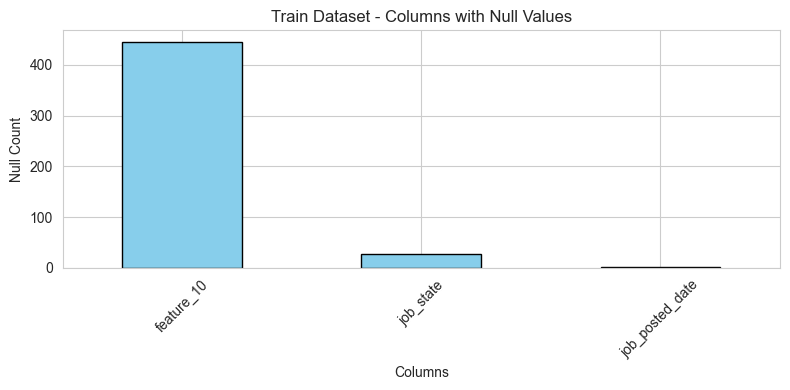

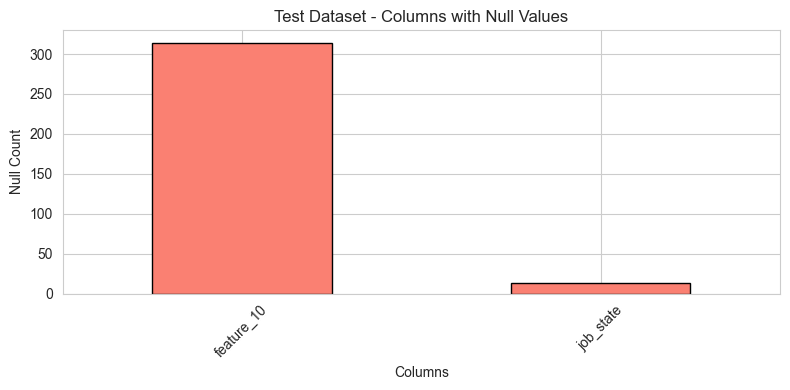

In [10]:
if len(train_nulls) > 0:
    plt.figure(figsize=(8, 4))
    train_nulls.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Train Dataset - Columns with Null Values')
    plt.xlabel('Columns')
    plt.ylabel('Null Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if len(test_nulls) > 0:
    plt.figure(figsize=(8, 4))
    test_nulls.sort_values(ascending=False).plot(kind='bar', color='salmon', edgecolor='black')
    plt.title('Test Dataset - Columns with Null Values')
    plt.xlabel('Columns')
    plt.ylabel('Null Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [11]:
feature_10_fill = df['feature_10'].median()

df['feature_10'] = df['feature_10'].fillna(feature_10_fill)
test['feature_10'] = test['feature_10'].fillna(feature_10_fill)

df['feature_10'] = df['feature_10'] / 6
test['feature_10'] = test['feature_10'] / 6

print("\nFeature_10 value counts after imputation and scaling (train):")
print(df['feature_10'].value_counts(dropna=False))

print("\nFeature_10 value counts after imputation and scaling (test):")
print(test['feature_10'].value_counts(dropna=False))


Feature_10 value counts after imputation and scaling (train):
feature_10
10.0    675
6.0     182
8.0     100
4.0      76
12.0     54
14.0     47
16.0     40
2.0      38
20.0     37
18.0      7
30.0      6
24.0      6
22.0      3
1.0       3
28.0      2
32.0      2
50.0      1
40.0      1
Name: count, dtype: int64

Feature_10 value counts after imputation and scaling (test):
feature_10
10.000000    461
6.000000     103
4.000000      71
8.000000      43
16.000000     41
20.000000     30
14.000000     29
12.000000     25
2.000000      23
24.000000     11
18.000000      3
28.000000      2
0.500000       2
22.000000      2
1.000000       2
50.000000      2
60.000000      1
40.000000      1
12.166667      1
26.000000      1
Name: count, dtype: int64


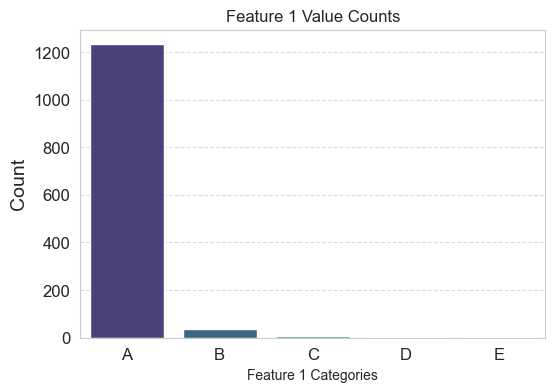


Train Feature_1 after grouping rare classes:
feature_1
A        1232
Other      48
Name: count, dtype: int64

Test Feature_1 after grouping rare classes:
feature_1
A        819
Other     35
Name: count, dtype: int64


In [12]:
feature1_counts = df['feature_1'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=feature1_counts.index, y=feature1_counts.values, palette="viridis")
plt.title('Feature 1 Value Counts', fontsize=12)
plt.xlabel('Feature 1 Categories', fontsize=10)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

rare_classes = ['B', 'C', 'D', 'E']
df['feature_1'] = df['feature_1'].replace(rare_classes, 'Other')
print("\nTrain Feature_1 after grouping rare classes:")
print(df['feature_1'].value_counts())

rare_classes = ['B', 'C', 'D', 'E']
test['feature_1'] = test['feature_1'].replace(rare_classes, 'Other')
print("\nTest Feature_1 after grouping rare classes:")
print(test['feature_1'].value_counts())

In [13]:
print("\nFeature_2 value counts:")
print(df['feature_2'].value_counts())

print("\nFeature_10 value counts:")
print(df['feature_10'].value_counts())


Feature_2 value counts:
feature_2
0.4640    18
0.4586    15
0.4195    13
0.4538    12
0.4262    12
          ..
0.6282     1
0.6823     1
0.6503     1
0.5930     1
0.6681     1
Name: count, Length: 871, dtype: int64

Feature_10 value counts:
feature_10
10.0    675
6.0     182
8.0     100
4.0      76
12.0     54
14.0     47
16.0     40
2.0      38
20.0     37
18.0      7
30.0      6
24.0      6
22.0      3
1.0       3
28.0      2
32.0      2
50.0      1
40.0      1
Name: count, dtype: int64


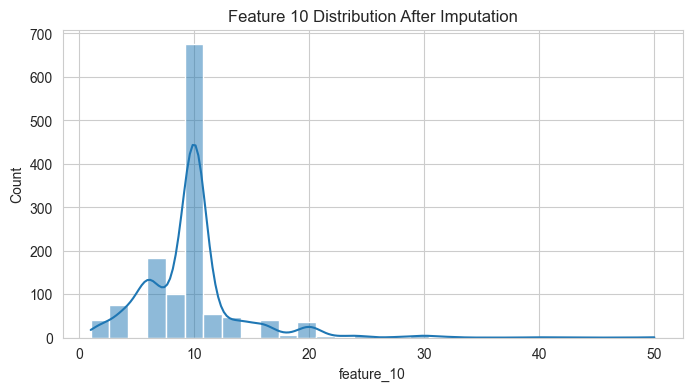

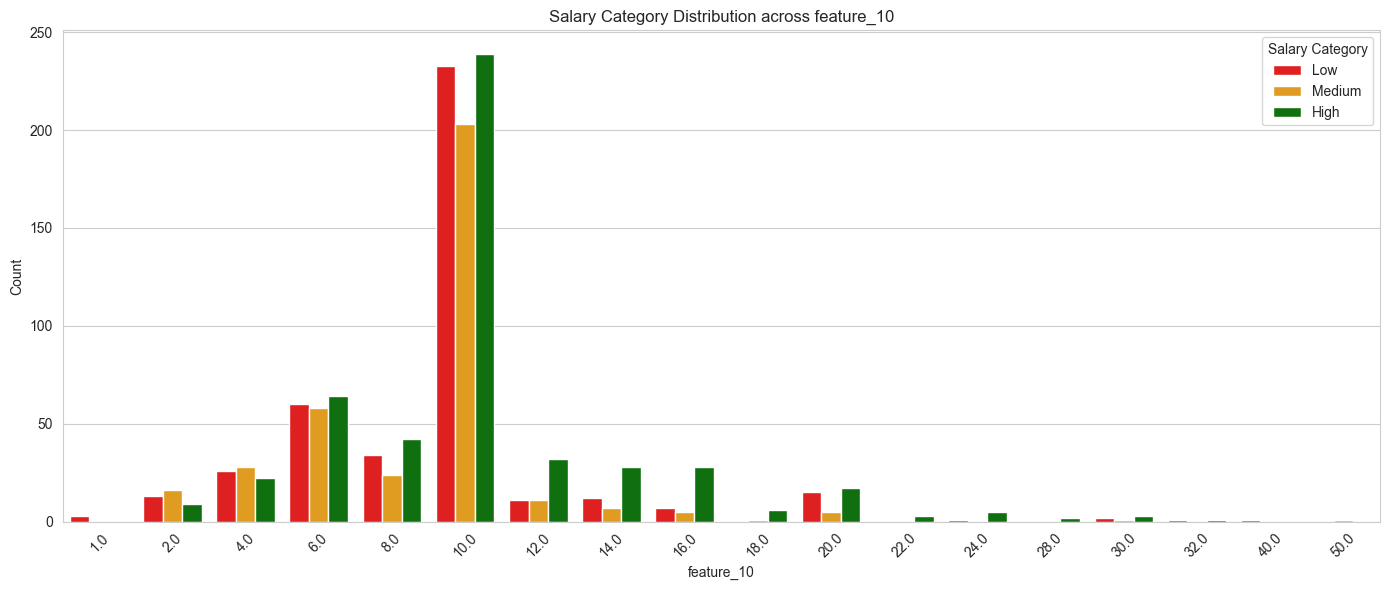


Salary Category vs Feature_10 Crosstab:
salary_category  High  Low  Medium
feature_10                        
1.0                 0    3       0
2.0                 9   13      16
4.0                22   26      28
6.0                64   60      58
8.0                42   34      24
10.0              239  233     203
12.0               32   11      11
14.0               28   12       7
16.0               28    7       5
18.0                6    0       1
20.0               17   15       5
22.0                3    0       0
24.0                5    1       0
28.0                2    0       0
30.0                3    2       1
32.0                1    1       0
40.0                0    1       0
50.0                0    0       1


In [14]:
plt.figure(figsize=(8, 4))
sns.histplot(df['feature_10'], bins=30, kde=True)
plt.title("Feature 10 Distribution After Imputation")
plt.show()

plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='feature_10', hue='salary_category',
              palette={'High': 'green', 'Medium': 'orange', 'Low': 'red'})
plt.title('Salary Category Distribution across feature_10')
plt.xlabel('feature_10')
plt.ylabel('Count')
plt.legend(title='Salary Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

salary_vs_f10 = pd.crosstab(df['feature_10'], df['salary_category'])
print("\nSalary Category vs Feature_10 Crosstab:")
print(salary_vs_f10)

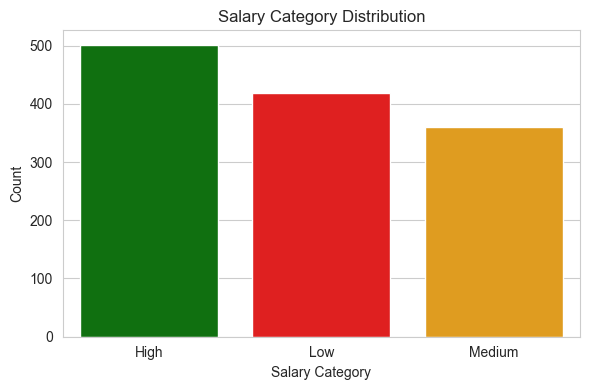

In [15]:
# =========================================================
# 11. EXTRA TARGET ANALYSIS PLOT
# =========================================================
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='salary_category', palette={'High': 'green', 'Medium': 'orange', 'Low': 'red'})
plt.title("Salary Category Distribution")
plt.xlabel("Salary Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [16]:
mode_date = df['job_posted_date'].mode()[0]
df['job_posted_date'].fillna(mode_date, inplace=True)

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'], format='%Y/%m')
df['job_posted_month'] = df['job_posted_date'].dt.month
df['job_posted_year'] = df['job_posted_date'].dt.year
df.drop(columns=['job_posted_date'], inplace=True)

test['job_posted_date'] = pd.to_datetime(test['job_posted_date'], format='%Y/%m')
test['job_posted_month'] = test['job_posted_date'].dt.month
test['job_posted_year'] = test['job_posted_date'].dt.year
test.drop(columns=['job_posted_date'], inplace=True)

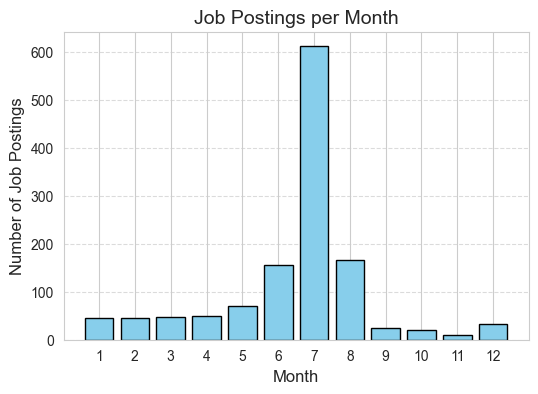

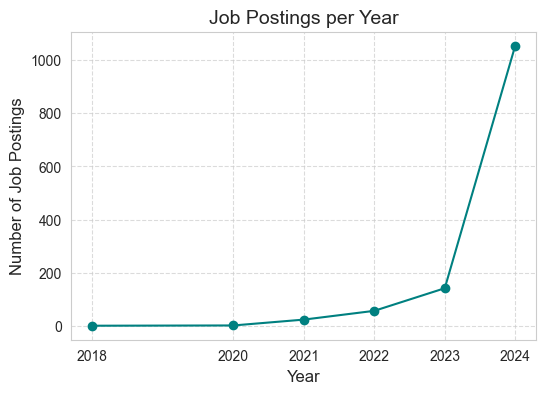

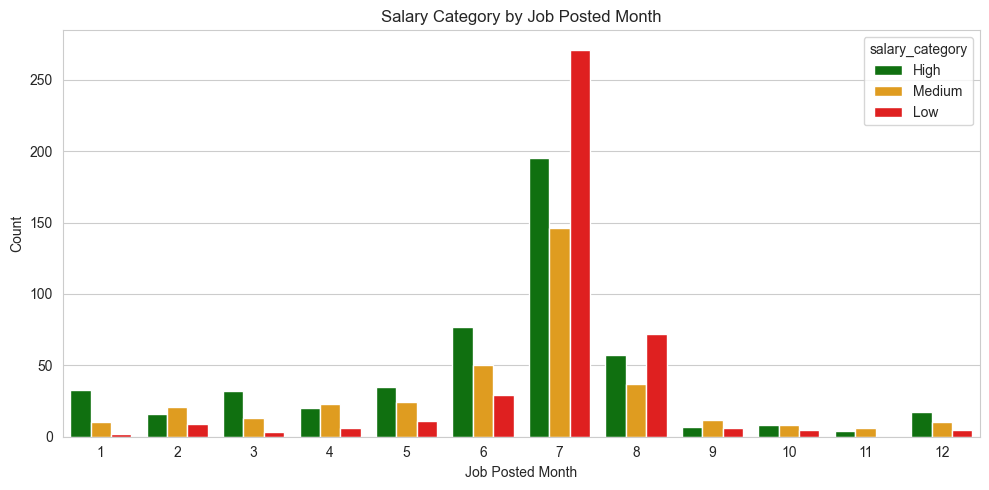

In [17]:
df = df[df['job_posted_month'].between(1, 12)]

month_counts = df['job_posted_month'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(month_counts.index, month_counts.values, color='skyblue', edgecolor='black')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Job Postings', fontsize=12)
plt.title('Job Postings per Month', fontsize=14)
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

year_counts = df['job_posted_year'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.plot(year_counts.index, year_counts.values, marker='o', linestyle='-', color='teal')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Job Postings', fontsize=12)
plt.title('Job Postings per Year', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(year_counts.index)
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='job_posted_month', hue='salary_category',
              palette={'High': 'green', 'Medium': 'orange', 'Low': 'red'})
plt.title("Salary Category by Job Posted Month")
plt.xlabel("Job Posted Month")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [18]:
mode_state = df['job_state'].mode()[0]
df['job_state'].fillna(mode_state, inplace=True)

mode_state = test['job_state'].mode()[0]
test['job_state'].fillna(mode_state, inplace=True)

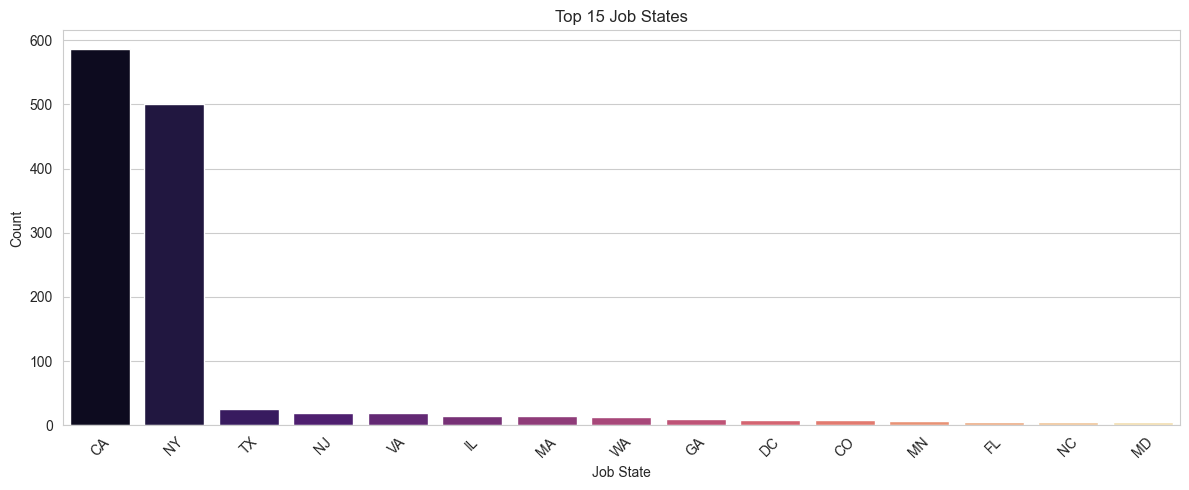

In [19]:
top_states = df['job_state'].value_counts().head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_states.index, y=top_states.values, palette='magma')
plt.title("Top 15 Job States")
plt.xlabel("Job State")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
categorical_columns = [
    'job_title', 'job_state',
    'feature_1', 'feature_3', 'feature_4', 'feature_5',
    'feature_6', 'feature_7', 'feature_8', 'feature_9',
    'feature_11', 'feature_12'
]

# Encode target separately
target_encoder = LabelEncoder()
df['salary_category'] = target_encoder.fit_transform(df['salary_category'].astype(str))

# Encode input categorical columns using combined train + test
for col in categorical_columns:
    le = LabelEncoder()
    combined_series = pd.concat([df[col].astype(str), test[col].astype(str)], axis=0)
    le.fit(combined_series)

    df[col] = le.transform(df[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

#### Initially I tried train-fit and test-transform encoding, but the test set contained unseen categories such as WY in job_state. Since this was a competition-style inference dataset, I used a unified label mapping across train and test feature categories to ensure consistent encoding without touching the target.

In [21]:
df.drop(['obs'], axis=1, inplace=True)

In [22]:
x = df.drop(columns=['salary_category'])
y = df['salary_category']

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

print("\nX_train shape:", x_train.shape)
print("Y_train shape:", y_train.shape)
print("X_val shape:", x_val.shape)
print("Y_val shape:", y_val.shape)


X_train shape: (1024, 316)
Y_train shape: (1024,)
X_val shape: (256, 316)
Y_val shape: (256,)


In [23]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)

In [24]:
log_model = LogisticRegression(max_iter=2000)
log_model.fit(x_train_scaled, y_train)
y_pred_log = log_model.predict(x_val_scaled)

accuracy_log = accuracy_score(y_val, y_pred_log)
print("\n================ LOGISTIC REGRESSION =================")
print(f"Logistic Regression Accuracy: {accuracy_log:.2f}\n")
print("Logistic Regression Classification Report:")
print(classification_report(y_val, y_pred_log))


================ LOGISTIC REGRESSION =================
Logistic Regression Accuracy: 0.63

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.66      0.66        94
           1       0.70      0.67      0.68        85
           2       0.53      0.55      0.54        77

    accuracy                           0.63       256
   macro avg       0.63      0.63      0.63       256
weighted avg       0.63      0.63      0.63       256



In [25]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_val)

accuracy_dt = accuracy_score(y_val, y_pred_dt)
print("\n================ DECISION TREE =================")
print(f"Accuracy: {accuracy_dt:.2f}\n")
print("Classification Report:")
print(classification_report(y_val, y_pred_dt))


================ DECISION TREE =================
Accuracy: 0.66

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.72      0.67        94
           1       0.79      0.68      0.73        85
           2       0.58      0.56      0.57        77

    accuracy                           0.66       256
   macro avg       0.67      0.65      0.66       256
weighted avg       0.67      0.66      0.66       256



In [26]:
rfc_model = RandomForestClassifier(random_state=42)
rfc_model.fit(x_train, y_train)
y_pred_rfc = rfc_model.predict(x_val)

accuracy_rfc = accuracy_score(y_val, y_pred_rfc)
print("\n================ RANDOM FOREST =================")
print(f"Accuracy: {accuracy_rfc:.2f}\n")
print("Classification Report:")
print(classification_report(y_val, y_pred_rfc))


================ RANDOM FOREST =================
Accuracy: 0.66

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.80      0.72        94
           1       0.77      0.60      0.68        85
           2       0.58      0.57      0.58        77

    accuracy                           0.66       256
   macro avg       0.67      0.66      0.66       256
weighted avg       0.67      0.66      0.66       256



In [27]:
xgb_model = XGBClassifier(
    objective='multi:softmax',
    subsample=0.7,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    enable_categorical=True,
    random_state=42
)

xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_val)

accuracy_xgb = accuracy_score(y_val, y_pred_xgb)
print("\n================ XGBOOST =================")
print(f"XGBoost Accuracy: {accuracy_xgb:.2f}\n")
print("XGBoost Classification Report:")
print(classification_report(y_val, y_pred_xgb))


================ XGBOOST =================
XGBoost Accuracy: 0.76

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.88      0.77        94
           1       0.91      0.73      0.81        85
           2       0.73      0.64      0.68        77

    accuracy                           0.76       256
   macro avg       0.78      0.75      0.75       256
weighted avg       0.77      0.76      0.76       256



In [28]:
catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=0
)

catboost_model.fit(x_train, y_train)
y_pred_catboost = catboost_model.predict(x_val)

accuracy_catboost = accuracy_score(y_val, y_pred_catboost)
print("\n================ CATBOOST =================")
print(f"CatBoost Accuracy: {accuracy_catboost:.2f}\n")
print("CatBoost Classification Report:")
print(classification_report(y_val, y_pred_catboost))


================ CATBOOST =================
CatBoost Accuracy: 0.75

CatBoost Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.86      0.76        94
           1       0.89      0.75      0.82        85
           2       0.72      0.60      0.65        77

    accuracy                           0.75       256
   macro avg       0.76      0.74      0.74       256
weighted avg       0.76      0.75      0.74       256



In [29]:
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

lgbm_model.fit(x_train, y_train)
y_pred_lgbm = lgbm_model.predict(x_val)

accuracy_lgbm = accuracy_score(y_val, y_pred_lgbm)
print("\n================ LIGHTGBM =================")
print(f"LightGBM Accuracy: {accuracy_lgbm:.2f}\n")
print("LightGBM Classification Report:")
print(classification_report(y_val, y_pred_lgbm))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008572 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76822
[LightGBM] [Info] Number of data points in the train set: 1024, number of used features: 315
[LightGBM] [Info] Start training from score -0.922659
[LightGBM] [Info] Start training from score -1.120331
[LightGBM] [Info] Start training from score -1.286025
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

================ LIGHTGBM =================
LightGBM Accuracy: 0.75

LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.87      0.77        94
           1       0.90      0.75      0.82        85
           2       0.72      0.61      0.66        77

    accuracy                           0.75       256
   macro avg       0.77      0.75      0.75       256
weighted avg       0.77      0.75      0.75  

In [30]:
model_results = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'CatBoost',
        'Logistic Regression',
        'LightGBM'
    ],
    'Accuracy': [
        accuracy_dt,
        accuracy_rfc,
        accuracy_xgb,
        accuracy_catboost,
        accuracy_log,
        accuracy_lgbm
    ]
}).sort_values(by='Accuracy', ascending=False)

print("\n================ MODEL COMPARISON =================")
print(model_results)


================ MODEL COMPARISON =================
                 Model  Accuracy
2              XGBoost  0.757812
5             LightGBM  0.753906
3             CatBoost  0.746094
1        Random Forest  0.664062
0        Decision Tree  0.660156
4  Logistic Regression  0.628906


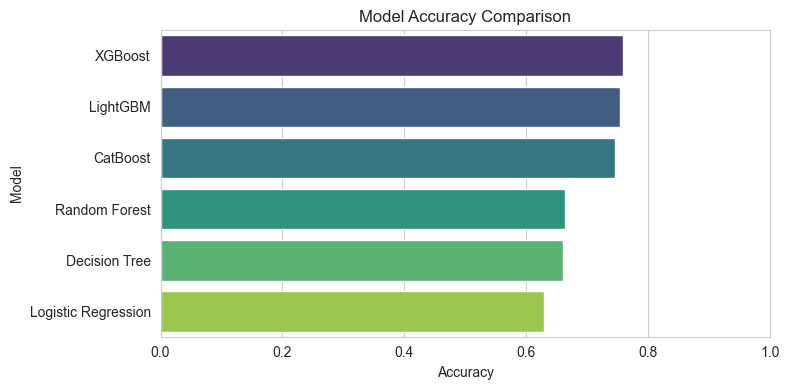

In [31]:
plt.figure(figsize=(8, 4))
sns.barplot(data=model_results, x='Accuracy', y='Model', palette='viridis')
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()